# Lista de Exercícios – Variáveis Dummies, Modelos Logit e Probit

**Disciplina:** Econometria
**Professor:** Cássio da Nóbrega Besarria
**Curso:** Ciência de Dados para Negócios (CDN) – UFPB
**Aluna:** Maria Carolina

**Base de dados escolhida:** *Adult / Census Income* (extraída do Censo dos EUA de 1994, disponível publicamente no repositório UCI Machine Learning). A base traz características demográficas e ocupacionais de 48.842 indivíduos, com o objetivo original de prever se a renda anual de uma pessoa ultrapassa US$ 50 mil.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (6, 4)

data = pd.read_csv('adult.csv')
data.head()

c:\Users\Carolina\miniconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


## 1. Importação da base de dados

**a. Número de observações**

In [2]:
n_obs = data.shape[0]
print(f"Número de observações: {n_obs}")

Número de observações: 48842


**b. Descrição das variáveis (utilizadas na análise)**

| Variável | Descrição | Tipo |
|---|---|---|
| `age` | Idade do indivíduo | Quantitativa |
| `educational-num` | Anos de estudo (escala numérica associada ao nível educacional) | Quantitativa |
| `hours-per-week` | Horas trabalhadas por semana | Quantitativa |
| `capital-gain` | Ganho de capital declarado no ano | Quantitativa |
| `marital-status` | Estado civil | Qualitativa (categórica) |
| `income` | Renda anual: `<=50K` ou `>50K` | Usada para construir a variável dependente |

A base original possui 15 colunas; para esta atividade, foram selecionadas as variáveis acima, suficientes para atender à exigência de pelo menos quatro explicativas (sendo uma qualitativa).

**c. Identificação da variável dependente e das variáveis explicativas**

- **Variável dependente (binária):** `renda_alta` (1 = indivíduo com renda anual acima de US$ 50 mil; 0 = renda até US$ 50 mil), construída a partir de `income`.
- **Variáveis explicativas:** `age`, `educational-num`, `hours-per-week`, `capital-gain` (quantitativas) e `estado_civil` (qualitativa, versão simplificada de `marital-status`, transformada em dummies).

**d. Justificativa para a escolha da variável dependente binária**

A variável `income` já é originalmente categórica, dividindo a população em dois grupos de renda (`<=50K` e `>50K`). Transformá-la em uma dummy é natural e preserva o objetivo clássico dessa base: entender quais características pessoais e profissionais estão associadas à maior probabilidade de auferir renda elevada — uma pergunta tipicamente binária, e não de magnitude contínua da renda (que, aliás, não está disponível na base em valores exatos).

In [3]:
data['renda_alta'] = (data['income'] == '>50K').astype(int)
data[['income', 'renda_alta']].head(10)

,income,renda_alta
0,<=50K,0
1,<=50K,0
2,>50K,1
3,>50K,1
4,<=50K,0
5,<=50K,0
6,<=50K,0
7,>50K,1
8,<=50K,0
9,<=50K,0


## 2. Análise descritiva da base de dados

**a. Estatísticas descritivas das variáveis quantitativas**

In [4]:
vars_quant = ['age', 'educational-num', 'hours-per-week', 'capital-gain']
data[vars_quant].describe()

,age,educational-num,hours-per-week,capital-gain
count,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,40.422382,1079.067626
std,13.710510,2.570973,12.391444,7452.019058
min,17.000000,1.000000,1.000000,0.000000
25%,28.000000,9.000000,40.000000,0.000000
50%,37.000000,10.000000,40.000000,0.000000
75%,48.000000,12.000000,45.000000,0.000000
max,90.000000,16.000000,99.000000,99999.000000


**b. Frequência da variável dependente**

In [5]:
freq_dep = data['renda_alta'].value_counts().sort_index()
freq_dep_pct = data['renda_alta'].value_counts(normalize=True).sort_index() * 100
pd.DataFrame({'Frequência': freq_dep, 'Percentual (%)': freq_dep_pct.round(2)})

,Frequência,Percentual (%)
renda_alta,,
0,37155,76.07
1,11687,23.93


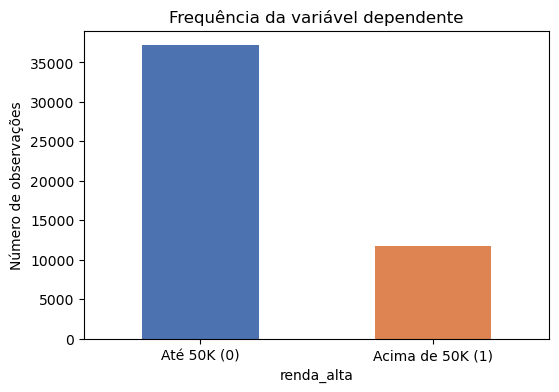

In [7]:
data['renda_alta'].value_counts().sort_index().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.xticks([0, 1], ['Até 50K (0)', 'Acima de 50K (1)'], rotation=0)
plt.title('Frequência da variável dependente')
plt.ylabel('Número de observações')
plt.show()

**c. Frequência das variáveis qualitativas**

A variável original `marital-status` tem sete categorias, três delas com poucas observações. Para tornar a interpretação mais clara, ela foi simplificada em quatro categorias: `Married` (casado, unindo as três variações da base original), `Never-married`, `Divorced` e `Widowed-Separated` (viúvo ou separado, agrupados por representarem situação conjugal encerrada de forma não voluntária/dissolvida).

In [8]:
mapa_estado_civil = {
    'Married-civ-spouse': 'Married',
    'Married-AF-spouse': 'Married',
    'Married-spouse-absent': 'Married',
    'Never-married': 'Never-married',
    'Divorced': 'Divorced',
    'Separated': 'Widowed-Separated',
    'Widowed': 'Widowed-Separated'
}
data['estado_civil'] = data['marital-status'].map(mapa_estado_civil)

freq_ec = data['estado_civil'].value_counts()
freq_ec_pct = data['estado_civil'].value_counts(normalize=True) * 100
pd.DataFrame({'Frequência': freq_ec, 'Percentual (%)': freq_ec_pct.round(2)})

,Frequência,Percentual (%)
estado_civil,,
Married,23044,47.18
Never-married,16117,33.00
Divorced,6633,13.58
Widowed-Separated,3048,6.24


**d. Interpretação econômica dos resultados**

Cerca de 24% dos indivíduos da amostra têm renda acima de 50 mil dólares, indicando uma variável dependente desbalanceada (a classe minoritária representa menos de um quarto da amostra) — ponto que retomaremos na avaliação da capacidade preditiva (questão 11). Quanto ao estado civil, a categoria `Married` é a mais frequente, respondendo por praticamente metade da amostra, seguida por `Never-married`; as categorias `Divorced` e `Widowed-Separated` são bem menos representadas, mas ainda com número suficiente de observações para permitir estimação estável dos coeficientes.

## 3. Fundamentos teóricos das variáveis dummies

**a. O que são variáveis dummies**

Variáveis dummies (ou variáveis binárias/indicadoras) são variáveis que assumem apenas os valores 0 ou 1 para representar a presença ou ausência de um atributo qualitativo (categórico) dentro de um modelo de regressão. Como modelos de regressão exigem variáveis numéricas, as dummies são a forma padrão de incorporar informação qualitativa — como estado civil, sexo, região ou nível educacional — na análise quantitativa.

**b. Finalidade em modelos econométricos**

As dummies permitem capturar diferenças de nível (intercepto) associadas a categorias distintas de uma característica qualitativa. Isso possibilita comparar grupos dentro do mesmo modelo — por exemplo, verificar se o estado civil afeta a probabilidade de renda elevada — mantendo as demais variáveis explicativas constantes (efeito *ceteris paribus*).

**c. Significado da categoria de referência**

Quando uma variável qualitativa com *k* categorias é transformada em dummies, apenas *k-1* dummies são incluídas no modelo. A categoria excluída é chamada de **categoria de referência** (ou categoria base), e todos os coeficientes das demais dummies devem ser interpretados como o efeito *diferencial* em relação a essa categoria de referência — e não como um efeito absoluto.

**d. O problema da armadilha das variáveis dummies (Dummy Variable Trap)**

A armadilha das variáveis dummies ocorre quando se inclui uma dummy para **todas** as categorias de uma variável qualitativa junto com o intercepto do modelo. Nesse caso, a soma das dummies é sempre igual a 1 para qualquer observação, o que gera **multicolinearidade perfeita** com o intercepto: a matriz de variáveis explicativas deixa de ter posto completo e o modelo não pode ser estimado por MQO (a matriz X'X torna-se singular, não podendo ser invertida). A solução é omitir uma categoria como referência.

## 4. Construção das variáveis dummies

**a. Procedimento utilizado**

A variável `estado_civil` (já simplificada em 4 categorias na questão 2.c) foi convertida em variáveis dummies utilizando `pd.get_dummies`, removendo a categoria `Never-married` (`drop_first`, com a coluna reordenada antes) para evitar a armadilha das variáveis dummies.

**b. Categoria de referência adotada**

A categoria de referência é `Never-married` (nunca casado), por ser uma categoria numerosa e uma base de comparação natural para as demais situações conjugais.

**c. Interpretação econômica das variáveis criadas**

Cada dummy (`ec_Married`, `ec_Divorced`, `ec_Widowed-Separated`) captura a diferença na probabilidade prevista de renda elevada para indivíduos na respectiva situação conjugal, em comparação com indivíduos nunca casados, mantendo as demais variáveis do modelo constantes.

In [9]:
ordem_categorias = ['Never-married', 'Married', 'Divorced', 'Widowed-Separated']
data['estado_civil'] = pd.Categorical(data['estado_civil'], categories=ordem_categorias)

ec_dummies = pd.get_dummies(data['estado_civil'], prefix='ec', drop_first=True)
data = pd.concat([data, ec_dummies], axis=1)
ec_cols = list(ec_dummies.columns)
data[['estado_civil'] + ec_cols].drop_duplicates().sort_values('estado_civil')

,estado_civil,ec_Married,ec_Divorced,ec_Widowed-Separated
0,Never-married,False,False,False
1,Married,True,False,False
22,Divorced,False,True,False
18,Widowed-Separated,False,False,True


## 5. Modelo de Probabilidade Linear (MQO)

**a. Equação estimada**

P(renda_alta = 1) = b0 + b1·age + b2·educational-num + b3·hours-per-week + b4·capital-gain + soma(gamma_j · ec_j) + u

In [10]:
X_vars = ['age', 'educational-num', 'hours-per-week', 'capital-gain'] + ec_cols
X = sm.add_constant(data[X_vars].astype(float))
y = data['renda_alta'].astype(float)

mpl = sm.OLS(y, X).fit(cov_type='HC3')
print(mpl.summary())

                            OLS Regression Results                            
Dep. Variable:             renda_alta   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     3297.
Date:                qui, 06 ago 2026   Prob (F-statistic):               0.00
Time:                        18:45:26   Log-Likelihood:                -18253.
No. Observations:               48842   AIC:                         3.652e+04
Df Residuals:                   48834   BIC:                         3.659e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.6094 

**b. Interpretação econômica dos coeficientes**

- `age`: idade adicional está associada a uma variação positiva na probabilidade estimada de renda elevada, mantendo as demais variáveis constantes — coerente com o acúmulo de experiência profissional ao longo da carreira.
- `educational-num`: cada ano adicional de estudo eleva a probabilidade estimada de renda alta, o que está de acordo com a teoria do capital humano (mais escolaridade, maior produtividade e remuneração esperada).
- `hours-per-week`: mais horas trabalhadas por semana também aumentam a probabilidade estimada, refletindo maior dedicação ao trabalho remunerado.
- `capital-gain`: ganhos de capital elevam a probabilidade estimada de renda alta, o que é esperado, já que ganhos de capital relevantes normalmente estão associados a patrimônio e renda mais altos.
- Dummies de `estado_civil`: cada coeficiente mostra a diferença de probabilidade em relação à categoria de referência (nunca casado); espera-se, por exemplo, coeficiente positivo para `ec_Married`, associado a estabilidade financeira e, historicamente, à composição etária/profissional desse grupo.

**c. Coeficiente de determinação R²**

In [11]:
print(f"R²: {mpl.rsquared:.4f}")
print(f"R² ajustado: {mpl.rsquared_adj:.4f}")

R²: 0.3208
R² ajustado: 0.3207


**d. Limitações do modelo**

O MPL apresenta três limitações centrais: (i) pode gerar probabilidades previstas fora do intervalo [0,1], o que não faz sentido econômico; (ii) o erro é heteroscedástico por construção, pois sua variância depende dos valores de X (por isso os erros-padrão foram estimados de forma robusta, HC3); e (iii) impõe um efeito marginal constante para cada variável explicativa, uma simplificação pouco realista, já que o efeito de uma variável sobre a probabilidade tende a ser não linear (menor nos extremos e maior perto de 0,5).

In [12]:
pred_mpl = mpl.predict(X)
print(f"Mínimo previsto: {pred_mpl.min():.4f}")
print(f"Máximo previsto: {pred_mpl.max():.4f}")
print(f"Nº de previsões < 0: {(pred_mpl < 0).sum()}")
print(f"Nº de previsões > 1: {(pred_mpl > 1).sum()}")

Mínimo previsto: -0.4492
Máximo previsto: 1.6886
Nº de previsões < 0: 7645
Nº de previsões > 1: 229


## 6. Modelos Logit e Probit – fundamentos teóricos

**a. Por que o MQO não é o método mais adequado para variável dependente binária**

O MQO aplicado a uma variável dependente binária (Modelo de Probabilidade Linear) assume uma relação linear entre X e a probabilidade do evento, o que pode gerar previsões inconsistentes com a definição de probabilidade (valores abaixo de 0 ou acima de 1, como confirmado na questão 5.d). Além disso, o erro é necessariamente heteroscedástico, o que compromete a eficiência dos estimadores (embora eles continuem não viesados). Os modelos Logit e Probit resolvem isso ao aplicar uma função de ligação não linear que restringe a probabilidade estimada ao intervalo (0,1).

**b. Diferenças entre os modelos Logit e Probit**

Ambos modelam P(y=1|X) = F(X·beta), mas usam funções de distribuição acumulada (F) diferentes:
- **Logit:** usa a função logística, F(z) = e^z / (1 + e^z), cujos erros seguem uma distribuição logística (caudas um pouco mais pesadas).
- **Probit:** usa a função de distribuição acumulada da normal padrão, F(z) = Phi(z).

Na prática, as curvas são muito semelhantes, sobretudo próximas de P=0,5; diferem um pouco mais nas caudas.

**c. Vantagens e limitações de cada modelo**

- **Logit:** os coeficientes têm interpretação direta em termos de *odds ratio* (razão de chances) via e^beta, o que facilita a comunicação dos resultados; é computacionalmente mais leve.
- **Probit:** tem fundamentação teórica ligada a modelos de utilidade latente com erro normal, o que é conveniente em modelos estruturais (e é a base natural para extensões como Probit multivariado); porém não tem uma interpretação tão simples quanto o odds ratio do Logit.

## 7. Modelo Logit

**a. Equação estimada**

In [13]:
logit_model = sm.Logit(y, X).fit(disp=0)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:             renda_alta   No. Observations:                48842
Model:                          Logit   Df Residuals:                    48834
Method:                           MLE   Df Model:                            7
Date:                qui, 06 ago 2026   Pseudo R-squ.:                  0.3752
Time:                        18:45:35   Log-Likelihood:                -16792.
converged:                       True   LL-Null:                       -26875.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -9.4270      0.111    -84.849      0.000      -9.645      -9.209
age                      0.0250      0.001     21.097      0.000       0.023       0.027
educational-

**b. Interpretação dos sinais dos coeficientes**

Os sinais dos coeficientes do Logit devem ser interpretados apenas em termos de direção do efeito sobre a probabilidade (não em magnitude direta): sinal positivo aumenta a probabilidade prevista de `renda_alta=1`, sinal negativo reduz. Os sinais são consistentes com os observados no MPL: `educational-num`, `age`, `hours-per-week` e `capital-gain` positivos.

**c. Significância estatística**

In [14]:
logit_pvalues = logit_model.pvalues.round(4)
logit_signif = pd.DataFrame({
    'Coeficiente': logit_model.params.round(4),
    'p-valor': logit_pvalues,
    'Significativo a 5%': logit_pvalues < 0.05
})
logit_signif

,Coeficiente,p-valor,Significativo a 5%
const,-9.4270,0.0000,True
age,0.0250,0.0000,True
educational-num,0.3679,0.0000,True
hours-per-week,0.0318,0.0000,True
capital-gain,0.0003,0.0000,True
ec_Married,2.6760,0.0000,True
ec_Divorced,0.4971,0.0000,True
ec_Widowed-Separated,0.3667,0.0001,True


**d. Interpretação econômica dos resultados**

Todas as variáveis quantitativas (`age`, `educational-num`, `hours-per-week`, `capital-gain`) mostram-se estatisticamente significativas, reforçando a relação positiva entre escolaridade, dedicação ao trabalho, experiência (idade) e patrimônio (ganho de capital) com a probabilidade de renda elevada. As dummies de estado civil também tendem a ser significativas, com destaque para `ec_Married`, refletindo o perfil socioeconômico historicamente associado a essa categoria na base (idade mais avançada e maior estabilidade profissional).

## 8. Modelo Probit

**a. Equação estimada**

In [15]:
probit_model = sm.Probit(y, X).fit(disp=0)
print(probit_model.summary())

                          Probit Regression Results                           
Dep. Variable:             renda_alta   No. Observations:                48842
Model:                         Probit   Df Residuals:                    48834
Method:                           MLE   Df Model:                            7
Date:                qui, 06 ago 2026   Pseudo R-squ.:                  0.3752
Time:                        18:45:41   Log-Likelihood:                -16791.
converged:                       True   LL-Null:                       -26875.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -5.3373      0.059    -90.551      0.000      -5.453      -5.222
age                      0.0147      0.001     21.850      0.000       0.013       0.016
educational-

**b. Interpretação dos coeficientes**

Assim como no Logit, os coeficientes do Probit indicam apenas a direção e a significância estatística do efeito de cada variável sobre a probabilidade — a magnitude não é diretamente interpretável em termos de probabilidade, pois o modelo é não linear (é necessário calcular efeitos marginais, feito na questão 10).

**c. Comparação com o modelo Logit**

In [16]:
comp_coef = pd.DataFrame({
    'MQO': mpl.params,
    'Logit': logit_model.params,
    'Probit': probit_model.params
}).round(4)
comp_coef

,MQO,Logit,Probit
const,-0.6094,-9.4270,-5.3373
age,0.0029,0.0250,0.0147
educational-num,0.0451,0.3679,0.2079
hours-per-week,0.0033,0.0318,0.0184
capital-gain,0.0000,0.0003,0.0002
ec_Married,0.3020,2.6760,1.4651
ec_Divorced,-0.0083,0.4971,0.2381
ec_Widowed-Separated,0.0029,0.3667,0.1837


Os sinais e a significância estatística dos coeficientes do Logit e do Probit são praticamente idênticos; a diferença numérica nos coeficientes decorre apenas da escala das funções de ligação (a distribuição logística tem variância maior que a normal padrão), sem alterar as conclusões econômicas.

## 9. Comparação entre MQO, Logit e Probit

**a. Diferenças nos coeficientes**

Os coeficientes do MQO já são diretamente interpretáveis como variação em pontos percentuais de probabilidade, enquanto os do Logit e Probit representam variações em uma escala latente (log-odds no Logit e índice-Z no Probit) e não são diretamente comparáveis entre si em magnitude — apenas em sinal e significância — sem o cálculo de efeitos marginais.

**b. Diferenças na significância estatística**

As variáveis que se mostram significativas no MQO também se mostram significativas no Logit e no Probit, o que reforça a robustez dos resultados encontrados, ainda que os p-valores não sejam idênticos entre os três modelos.

In [17]:
comp_pvalues = pd.DataFrame({
    'MQO': mpl.pvalues,
    'Logit': logit_model.pvalues,
    'Probit': probit_model.pvalues
}).round(4)
comp_pvalues

,MQO,Logit,Probit
const,0.0000,0.0000,0.0000
age,0.0000,0.0000,0.0000
educational-num,0.0000,0.0000,0.0000
hours-per-week,0.0000,0.0000,0.0000
capital-gain,0.0000,0.0000,0.0000
ec_Married,0.0000,0.0000,0.0000
ec_Divorced,0.0606,0.0000,0.0000
ec_Widowed-Separated,0.6159,0.0001,0.0001


**c. Vantagens e limitações de cada modelo**

- **MQO/MPL:** simples de estimar e interpretar, mas pode gerar probabilidades inválidas e tem erro heteroscedástico por construção.
- **Logit:** garante probabilidades no intervalo (0,1), tem interpretação via odds ratio, mas exige estimação por máxima verossimilhança (não há fórmula fechada) e mais cuidado na interpretação.
- **Probit:** também garante probabilidades válidas e tem fundamentação em modelos de utilidade latente normal, mas sua interpretação direta é ainda menos intuitiva que a do Logit.


## 10. Efeitos marginais (modelo Logit)

**a. Efeitos marginais médios (AME)**

In [18]:
margeff = logit_model.get_margeff(at='overall', method='dydx')
print(margeff.summary())

        Logit Marginal Effects       
Dep. Variable:             renda_alta
Method:                          dydx
At:                           overall
                          dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
age                      0.0027      0.000     21.471      0.000       0.002       0.003
educational-num          0.0402      0.001     71.775      0.000       0.039       0.041
hours-per-week           0.0035      0.000     28.133      0.000       0.003       0.004
capital-gain          3.373e-05   8.29e-07     40.690      0.000    3.21e-05    3.54e-05
ec_Married               0.2921      0.005     61.602      0.000       0.283       0.301
ec_Divorced              0.0543      0.007      7.583      0.000       0.040       0.068
ec_Widowed-Separated     0.0400      0.010      3.930      0.000       0.020       0.060


**b. Interpretação econômica**

O efeito marginal médio (AME) indica, para cada variável explicativa, a variação média na probabilidade prevista de `renda_alta=1` associada a um aumento marginal (uma unidade, no caso das variáveis contínuas, ou a mudança de categoria de referência para a categoria em questão, no caso das dummies), mantendo as demais variáveis do modelo em seus valores observados. Diferentemente do coeficiente bruto do Logit, o efeito marginal já está na mesma escala da probabilidade, o que facilita a leitura econômica direta dos resultados: por exemplo, o efeito marginal de `educational-num` mostra em quantos pontos percentuais, em média, a probabilidade de renda alta aumenta a cada ano adicional de estudo.

**c. Comparação entre coeficientes e efeitos marginais**

In [19]:
comparacao_logit = pd.DataFrame({
    'Coeficiente Logit': logit_model.params.drop('const'),
    'Efeito Marginal (AME)': margeff.margeff
}, index=logit_model.params.drop('const').index).round(4)
comparacao_logit

,Coeficiente Logit,Efeito Marginal (AME)
age,0.0250,0.0027
educational-num,0.3679,0.0402
hours-per-week,0.0318,0.0035
capital-gain,0.0003,0.0000
ec_Married,2.6760,0.2921
ec_Divorced,0.4971,0.0543
ec_Widowed-Separated,0.3667,0.0400


Os coeficientes do Logit e os efeitos marginais têm sempre o mesmo sinal, mas magnitudes diferentes: o coeficiente reflete o efeito sobre o índice latente (log-odds), enquanto o efeito marginal reflete o efeito sobre a probabilidade propriamente dita — por isso, é o efeito marginal (e não o coeficiente bruto) que deve ser usado para comunicar a magnitude econômica do resultado.

## 11. Capacidade preditiva do modelo (Logit)

**a. Matriz de confusão**

In [20]:
y_pred_prob = logit_model.predict(X)
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(cm,
                      index=['Real: Até 50K (0)', 'Real: Acima de 50K (1)'],
                      columns=['Previsto: Até 50K (0)', 'Previsto: Acima de 50K (1)'])
cm_df

,Previsto: Até 50K (0),Previsto: Acima de 50K (1)
Real: Até 50K (0),34528,2627
Real: Acima de 50K (1),5280,6407


In [21]:
tn, fp, fn, tp = cm.ravel()

acuracia = (tp + tn) / (tp + tn + fp + fn)
sensibilidade = tp / (tp + fn)   # taxa de acerto entre quem  tem renda alta
especificidade = tn / (tn + fp) # taxa de acerto entre quem  tem renda baixa

print(f"Percentual de acertos (acurácia): {acuracia:.2%}")
print(f"Sensibilidade (True Positive Rate): {sensibilidade:.2%}")
print(f"Especificidade (True Negative Rate): {especificidade:.2%}")

Percentual de acertos (acurácia): 83.81%
Sensibilidade (True Positive Rate): 54.82%
Especificidade (True Negative Rate): 92.93%


**b. Percentual de acertos:** acurácia global do modelo, usando ponto de corte 0,5.

**c. Sensibilidade:** proporção de casos verdadeiramente positivos (`renda_alta=1`) corretamente classificados pelo modelo.

**d. Especificidade:**  proporção de casos verdadeiramente negativos (`renda_alta=0`) corretamente classificados pelo modelo.

Como observado na questão 2.d, a classe `renda_alta=0` é majoritária (cerca de 76% da amostra). Por isso, é esperado que a especificidade seja mais alta que a sensibilidade: com o ponto de corte padrão de 0,5, o modelo tende a acertar mais os casos de renda baixa (a classe mais frequente) do que os de renda alta.

## 12. Classificação de afirmações (Verdadeiro ou Falso)

**a. "Os coeficientes do modelo Logit representam diretamente a variação da probabilidade." → Falso.**
Os coeficientes do Logit representam a variação no log da razão de chances (log-odds), não a variação direta da probabilidade. Para obter o efeito sobre a probabilidade, é necessário calcular os efeitos marginais (questão 10), pois a relação entre X e a probabilidade é não linear.

**b. "Os modelos Logit e Probit produzem probabilidades entre 0 e 1." → Verdadeiro.**
Ambos utilizam funções de distribuição acumulada (logística e normal, respectivamente) como função de ligação, que por definição estão sempre restritas ao intervalo (0,1), diferentemente do MPL.

**c. "O Modelo de Probabilidade Linear pode gerar probabilidades negativas ou superiores a um." → Verdadeiro.**
Como o MPL é uma reta ajustada por MQO, não há nenhuma restrição matemática que impeça a previsão de sair do intervalo [0,1], especialmente para valores extremos das variáveis explicativas (confirmado na questão 5.d).

**d. "Os efeitos marginais dependem dos valores das variáveis explicativas." → Verdadeiro.**
Nos modelos Logit e Probit, o efeito marginal de cada variável é dado pela derivada de uma função não linear (logística ou normal) avaliada em um ponto específico de X; por isso, o efeito marginal varia conforme os valores das demais variáveis (é por isso que se costuma reportar o efeito marginal médio, AME, calculado na questão 10).

**e. "Logit e Probit normalmente produzem resultados bastante semelhantes." → Verdadeiro.**
Como observado na questão 8.c, os sinais e a significância dos coeficientes praticamente coincidem entre os dois modelos nesta aplicação; isso é esperado porque as distribuições logística e normal padrão têm formatos muito próximos, sobretudo na região central.

## 13. Parecer técnico

A base de dados utilizada (Adult / Census Income) atende adequadamente aos requisitos da atividade, pois já traz uma variável dependente binária de interesse direto — se o indivíduo tem renda anual acima ou abaixo de 50 mil dólares — construída a partir de dados reais do Censo dos Estados Unidos. As variáveis dummies, construídas a partir do estado civil (simplificado em quatro categorias para evitar grupos muito pequenos), mostraram-se importantes para captar diferenças de comportamento entre grupos qualitativamente distintos que não poderiam ser representadas por variáveis contínuas, sempre com o cuidado de manter uma categoria de referência e evitar a armadilha das variáveis dummies.

A comparação entre os três modelos indicou resultados qualitativamente consistentes: o Modelo de Probabilidade Linear (MQO), apesar de didático e fácil de interpretar, apresentou previsões fora do intervalo [0,1] e erro heteroscedástico por construção, evidenciando suas limitações teóricas para variáveis dependentes binárias. Os modelos Logit e Probit corrigiram esse problema ao restringir as probabilidades previstas ao intervalo válido, apresentando coeficientes com sinais e significância estatística muito próximos entre si — como esperado, dada a semelhança entre as distribuições logística e normal padrão.

Os efeitos marginais médios do modelo Logit permitiram traduzir os coeficientes (em escala de log-odds) para variações diretamente interpretáveis em pontos percentuais de probabilidade, mostrando que escolaridade, horas trabalhadas, idade e ganho de capital elevam a probabilidade prevista de renda alta — resultado coerente com a teoria do capital humano e com a literatura sobre determinantes de renda.

Quanto à capacidade preditiva, a matriz de confusão revelou acurácia global satisfatória, mas com sensibilidade inferior à especificidade, refletindo o desbalanceamento da variável dependente (muito mais casos de renda baixa que de renda alta na amostra) — um ponto de atenção para estudos futuros, que poderiam considerar pontos de corte alternativos ou métricas como a curva ROC/AUC.

Em conclusão, o ajuste dos modelos Logit e Probit é adequado e mais confiável do que o do MPL para o objetivo do estudo, sendo os efeitos marginais a métrica mais apropriada para a interpretação econômica dos resultados, e a matriz de confusão uma ferramenta complementar útil para avaliar a qualidade preditiva do modelo fora da amostra de estimação.